Saved animation: /Users/luciereymondet/GitHub/GOFLOW_LR/plots/202502020000_202502020200_ir_105.mp4


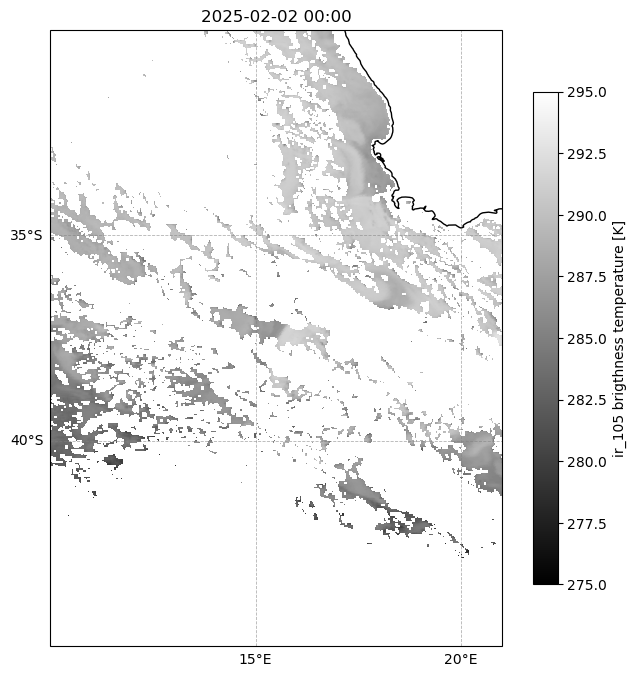

In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
import os
from glob import glob
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker

# -----------------------------
# HELPER FUNCTION
# -----------------------------
def format_gl(ax):
    gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.6,
    color='gray',
    alpha=0.6,
    linestyle='--')
    # Only label left & bottom (map standard)
    gl.top_labels = False
    gl.right_labels = False
    # Control tick spacing
    gl.xlocator = MultipleLocator(5.0)
    gl.ylocator = MultipleLocator(5.0)
    # Label formatting
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}


# -----------------------------
# PATHS
# -----------------------------
dirin = '/Users/luciereymondet/GitHub/GOFLOW_LR/data/processed'
dirout = '/Users/luciereymondet/GitHub/GOFLOW_LR/plots'
os.makedirs(dirout, exist_ok=True)

# -----------------------------
# TIME RANGE
# -----------------------------
start, end = '202502020000', '202502020200'
dates = pd.date_range(
    start=pd.to_datetime(start, format="%Y%m%d%H%M"),
    end=pd.to_datetime(end, format="%Y%m%d%H%M"),
    freq="10min",
    inclusive="left"
)
dates_str = dates.strftime("%Y%m%d%H%M").tolist()

# -----------------------------
# DATA SELECTION
# channels in 1C-RRAD are ['ir_105','ir_123','ir_133','ir_38','ir_87','ir_97',
# 'nir_13','nir_16','nir_22',
# 'vis_04','vis_05','vis_06','vis_08','vis_09',
# 'wv_63', 'wv_73']
# channels in 2-CLM are ['cloud_mask']
# -----------------------------

product = '1C-RRAD_nc'
channel = 'ir_105'

files = [
    fname
    for d in dates_str
    for fname in glob(os.path.join(dirin, product, f"{d}*.nc"))]

ds = xr.open_mfdataset(
    files,
    combine='nested',
    concat_dim='time')[channel]

ds = ds.assign_coords(time=('time', dates))

files_clm = [
    fname
    for d in dates_str
    for fname in glob(os.path.join(dirin, '2-CLM_nc', f"{d}*.nc"))]

ds_clm = xr.open_mfdataset(
    files_clm,
    combine='nested',
    concat_dim='time')['cloud_mask']

ds_clm = ds_clm.assign_coords(time=('time', dates))

lon_min, lon_max, lat_min, lat_max = ds.x.min().item(), ds.x.max().item(), ds.y.min().item(), ds.y.max().item()
# -----------------------------
# PLOT SETUP
# -----------------------------
da0 = ds.isel(time=0)
cld = ds_clm.isel(time=0)

da_clear = xr.where(
    cld == 0,
    da0,
    np.nan
)

extent = [lon_min, lon_max, lat_min, lat_max]

fig, ax = plt.subplots(figsize=(8,8),subplot_kw={'projection': ccrs.PlateCarree()})
format_gl(ax)

im = ax.imshow(
    da_clear,
    extent=extent,
    origin="upper",
    cmap='gray', vmin=275, vmax=295,
    transform=ccrs.PlateCarree()
)

ax.coastlines()
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
cb = plt.colorbar(im, ax=ax, orientation='vertical', shrink=0.8)
cb.set_label(f'{channel} brigthness temperature [K]')

# -----------------------------
# ANIMATION FUNCTION
# -----------------------------
def update(frame):
    da_clear = xr.where(
        ds_clm.isel(time=frame) == 0,
        ds.isel(time=frame),
        np.nan
        )
    im.set_array(da_clear)
    titre = dates[frame].strftime('%Y-%m-%d %H:%M')
    ax.set_title(titre)
    return im

ani = FuncAnimation(
    fig,
    update,
    frames=len(dates),
    blit=False
)

# -----------------------------
# SAVE MOVIE
# -----------------------------
outfile = os.path.join(dirout, f'{start}_{end}_{channel}.mp4')
ani.save(outfile, writer='ffmpeg', fps=6, bitrate=10000)

print(f"Saved animation: {outfile}")


In [23]:
print(ds_clm.attrs)


{'end_time': '2025-02-02 00:10:00', 'file_type': 'grib_fci_clm', 'flag_meanings': ['clear sky over water', 'clear sky over land', 'cloudy', 'undefined'], 'flag_values': array([0, 1, 2, 3]), 'grid_mapping': 'geo_area', 'long_name': 'Cloud Classification', 'modifiers': array([], dtype=float64), 'orbital_parameters': '{"projection_longitude": 0.0}', 'parameter_number': 7, 'platform_name': 'MTG-i1', 'reader': 'fci_l2_grib', 'resolution': 2000, 'sensor': 'fci', 'standard_name': 'cloud_classification', 'start_time': '2025-02-02 00:00:00', 'units': '1'}
